# ⚡ Notebook 4 — Real-Time Alert Simulation
**Project:** Real-Time Customer Churn Analysis Agent  
**Input:** `models/best_model.pkl` · `models/model_metadata.json` · `data/feature_metadata.json` · `data/telco_churn_features.csv`  
**Output:** `data/synthetic_streams/events_stream.jsonl` · `data/synthetic_streams/alert_log.csv`

### What this notebook does
```
  ┌─────────────────────┐      ┌──────────────────────┐      ┌─────────────────────┐
  │  Synthetic Event    │ ───► │   Feature Pipeline   │ ───► │   Churn Agent       │
  │  Generator          │      │  (same transforms    │      │  • score event      │
  │  (JSON stream)      │      │   as training)       │      │  • threshold check  │
  └─────────────────────┘      └──────────────────────┘      │  • fire alert       │
                                                              │  • log result       │
                                                              └─────────────────────┘
```

| Step | What happens |
|------|--------------|
| 1 | Load model + metadata |
| 2 | Generate synthetic streaming events (JSON-L file) |
| 3 | Build the real-time scoring pipeline |
| 4 | Simulate the event stream — score each event, fire alerts |
| 5 | Visualise alert dashboard |
| 6 | Save alert log |

---

## 1. Imports & Load Artefacts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json, os, pickle, time, random, warnings
from datetime import datetime, timedelta
from collections import deque

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

os.makedirs('../data/synthetic_streams', exist_ok=True)

# ── load model ─────────────────────────────────────────────────────────────────
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../models/model_metadata.json') as f:
    model_meta = json.load(f)

with open('../data/feature_metadata.json') as f:
    feat_meta = json.load(f)

THRESHOLD      = model_meta['best_threshold']
FEATURE_COLS   = feat_meta['feature_columns']

print(f'Model loaded       : {model_meta["model_type"]}')
print(f'Alert threshold    : {THRESHOLD}')
print(f'Feature count      : {len(FEATURE_COLS)}')

Model loaded       : RandomForestClassifier
Alert threshold    : 0.35
Feature count      : 39


In [2]:
# ── load scaler (needed for continuous columns) ───────────────────────────────
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

SCALE_COLS = feat_meta['scaled_columns']
print('Scaler loaded  ✔')
print('Scaled columns:', SCALE_COLS)

Scaler loaded  ✔
Scaled columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'charges_per_month_ratio', 'risk_score']


In [3]:
# ── reference data for realistic sampling distributions ───────────────────────
df_ref = pd.read_csv('../data/telco_churn_features.csv')
print(f'Reference data loaded  :  {df_ref.shape}')

Reference data loaded  :  (7021, 40)


---
## 2. Synthetic Event Generator

Each event represents a **customer activity ping** — e.g. a usage record, a billing event, or a support call.  
We generate events by sampling from the real dataset with small random perturbations so the stream looks live.

In [4]:
def generate_event(customer_id: int, base_row: pd.Series, timestamp: datetime) -> dict:
    """
    Create a single synthetic streaming event by slightly perturbing a reference row.
    Returns a plain dict (JSON-serialisable).
    """
    row = base_row.copy()

    # ── small random perturbations to continuous features ─────────────────────
    # (simulate month-over-month changes in customer behaviour)
    row['MonthlyCharges']          = max(0, row['MonthlyCharges'] + np.random.normal(0, 0.05))
    row['tenure']                  = max(0, row['tenure']         + np.random.normal(0, 0.02))
    row['avg_monthly_spend']       = max(0, row['avg_monthly_spend'] + np.random.normal(0, 0.03))
    row['charges_per_month_ratio'] = max(0, row['charges_per_month_ratio'] + np.random.normal(0, 0.01))

    # ── occasionally flip a service flag (customer adds / removes a service) ──
    service_flags = [c for c in FEATURE_COLS if c.endswith('_Yes')]
    if random.random() < 0.05 and service_flags:          # 5 % chance
        flip_col = random.choice(service_flags)
        row[flip_col] = 1 - row[flip_col]
        row['num_services'] = max(0, row['num_services'] + (1 if row[flip_col] else -1))

    event = {
        'customer_id'  : f'CUST-{customer_id:05d}',
        'timestamp'    : timestamp.isoformat(),
        'features'     : {col: float(row[col]) if col in row.index else 0.0
                          for col in FEATURE_COLS}
    }
    return event


print('Event generator defined ✔')

Event generator defined ✔


In [5]:
# ── generate N_EVENTS events spread across 24 hours ──────────────────────────
N_EVENTS     = 500
START_TIME   = datetime(2024, 6, 1, 0, 0, 0)
INTERVAL_SEC = 86400 // N_EVENTS           # evenly spaced across 24 h

events_path = '../data/synthetic_streams/events_stream.jsonl'

X_ref = df_ref.drop(columns='Churn')       # features only

with open(events_path, 'w') as fout:
    for i in range(N_EVENTS):
        # pick a random reference customer
        idx      = random.randint(0, len(X_ref) - 1)
        base_row = X_ref.iloc[idx]
        ts       = START_TIME + timedelta(seconds=i * INTERVAL_SEC)

        event = generate_event(customer_id=idx, base_row=base_row, timestamp=ts)
        fout.write(json.dumps(event) + '\n')

print(f'✅  {N_EVENTS} synthetic events written → {events_path}')

# preview first 2 events
with open(events_path) as f:
    for _ in range(2):
        evt = json.loads(f.readline())
        print(json.dumps({k: v for k, v in evt.items() if k != 'features'}, indent=2))
        print('  features (first 5):', dict(list(evt['features'].items())[:5]))
        print()

✅  500 synthetic events written → ../data/synthetic_streams/events_stream.jsonl
{
  "customer_id": "CUST-05238",
  "timestamp": "2024-06-01T00:00:00"
}
  features (first 5): {'gender': 1.0, 'SeniorCitizen': 0.0, 'Partner': 0.0, 'Dependents': 1.0, 'tenure': 1.6085419790843285}

{
  "customer_id": "CUST-06074",
  "timestamp": "2024-06-01T00:02:52"
}
  features (first 5): {'gender': 0.0, 'SeniorCitizen': 0.0, 'Partner': 0.0, 'Dependents': 0.0, 'tenure': 0.0}



---
## 3. Real-Time Scoring Pipeline

This is the core of the agent — a function that receives one event and returns a churn score + alert decision.

In [6]:
def score_event(event: dict) -> dict:
    """
    Takes a single streaming event dict.
    Returns the same dict enriched with:
        churn_probability, alert, risk_tier, processing_time_ms
    """
    t0 = time.perf_counter()

    # ── 1. reconstruct feature vector ─────────────────────────────────────────
    feat_dict = event['features']
    row       = pd.DataFrame([{col: feat_dict.get(col, 0.0) for col in FEATURE_COLS}])

    # ── 2. apply the same scaling used during training ─────────────────────────
    present_scale_cols = [c for c in SCALE_COLS if c in row.columns]
    row[present_scale_cols] = scaler.transform(row[present_scale_cols])

    # ── 3. predict ─────────────────────────────────────────────────────────────
    prob  = float(model.predict_proba(row)[0][1])
    alert = prob >= THRESHOLD

    # ── 4. assign risk tier ────────────────────────────────────────────────────
    if prob >= 0.75:
        tier = 'CRITICAL'
    elif prob >= THRESHOLD:
        tier = 'HIGH'
    elif prob >= 0.30:
        tier = 'MEDIUM'
    else:
        tier = 'LOW'

    elapsed_ms = round((time.perf_counter() - t0) * 1000, 2)

    return {
        'customer_id'       : event['customer_id'],
        'timestamp'         : event['timestamp'],
        'churn_probability' : round(prob, 4),
        'alert'             : alert,
        'risk_tier'         : tier,
        'processing_time_ms': elapsed_ms
    }


print('Scoring pipeline defined ✔')

# quick smoke-test
with open(events_path) as f:
    test_evt = json.loads(f.readline())
result = score_event(test_evt)
print('\nSample score result:')
print(json.dumps(result, indent=2))

Scoring pipeline defined ✔

Sample score result:
{
  "customer_id": "CUST-05238",
  "timestamp": "2024-06-01T00:00:00",
  "churn_probability": 0.086,
  "alert": false,
  "risk_tier": "LOW",
  "processing_time_ms": 76.45
}


---
## 4. Stream Simulation — Score Every Event & Fire Alerts

In [7]:
# ── alert console helper ──────────────────────────────────────────────────────
TIER_EMOJI = {'CRITICAL': '🔴', 'HIGH': '🟠', 'MEDIUM': '🟡', 'LOW': '🟢'}

def print_alert(result: dict):
    emoji = TIER_EMOJI[result['risk_tier']]
    print(f"{emoji}  [{result['timestamp'][:19]}]  "
          f"{result['customer_id']:12s}  "
          f"prob={result['churn_probability']:.3f}  "
          f"tier={result['risk_tier']:8s}  "
          f"({result['processing_time_ms']} ms)")

In [8]:
scored_events  = []    # all results
alert_events   = []    # only fired alerts

# rolling window for live throughput tracking
window_size    = 50
time_window    = deque(maxlen=window_size)

print(f'▶  Simulating stream  ({N_EVENTS} events, threshold={THRESHOLD})\n')
print(f'{"─"*75}')

with open(events_path) as f:
    for line_no, line in enumerate(f, 1):
        event  = json.loads(line.strip())
        result = score_event(event)

        scored_events.append(result)
        time_window.append(result['processing_time_ms'])

        if result['alert']:
            alert_events.append(result)
            print_alert(result)

        # progress ticker every 100 events
        if line_no % 100 == 0:
            avg_ms = np.mean(time_window)
            print(f'   ── {line_no:>4} / {N_EVENTS} events processed  '
                  f'│  alerts so far: {len(alert_events):>3}  '
                  f'│  avg latency: {avg_ms:.2f} ms  ──')

print(f'\n{"─"*75}')
print(f'✅  Stream complete')
print(f'   Total events   : {len(scored_events)}')
print(f'   Alerts fired   : {len(alert_events)}  ({len(alert_events)/len(scored_events)*100:.1f}%)')
print(f'   Avg latency    : {np.mean([e["processing_time_ms"] for e in scored_events]):.2f} ms / event')

▶  Simulating stream  (500 events, threshold=0.35)

───────────────────────────────────────────────────────────────────────────
🟠  [2024-06-01T00:02:52]  CUST-06074    prob=0.697  tier=HIGH      (41.08 ms)
🟠  [2024-06-01T00:05:44]  CUST-01828    prob=0.460  tier=HIGH      (41.17 ms)
🟠  [2024-06-01T00:11:28]  CUST-04467    prob=0.569  tier=HIGH      (41.24 ms)
🟠  [2024-06-01T00:14:20]  CUST-03456    prob=0.472  tier=HIGH      (41.21 ms)
🟠  [2024-06-01T00:17:12]  CUST-01791    prob=0.480  tier=HIGH      (40.47 ms)
🟠  [2024-06-01T00:20:04]  CUST-04931    prob=0.354  tier=HIGH      (42.56 ms)
🟠  [2024-06-01T00:40:08]  CUST-02276    prob=0.380  tier=HIGH      (42.08 ms)
🟠  [2024-06-01T00:51:36]  CUST-04945    prob=0.448  tier=HIGH      (42.59 ms)
🟠  [2024-06-01T00:54:28]  CUST-00355    prob=0.538  tier=HIGH      (41.65 ms)
🟠  [2024-06-01T00:57:20]  CUST-04392    prob=0.419  tier=HIGH      (41.57 ms)
🟠  [2024-06-01T01:03:04]  CUST-02401    prob=0.511  tier=HIGH      (41.5 ms)
🟠  [2024-06-01T

---
## 5. Alert Dashboard Visualisations

In [9]:
scored_df = pd.DataFrame(scored_events)
scored_df['timestamp'] = pd.to_datetime(scored_df['timestamp'])
scored_df['hour']      = scored_df['timestamp'].dt.hour

alert_df  = scored_df[scored_df['alert']]

scored_df.head(4)

,customer_id,timestamp,churn_probability,alert,risk_tier,processing_time_ms,hour
0,CUST-05238,2024-06-01 00:00:00,0.0860,False,LOW,42.47,0
1,CUST-06074,2024-06-01 00:02:52,0.6969,True,HIGH,41.08,0
2,CUST-01828,2024-06-01 00:05:44,0.4604,True,HIGH,41.17,0
3,CUST-00839,2024-06-01 00:08:36,0.1167,False,LOW,42.44,0


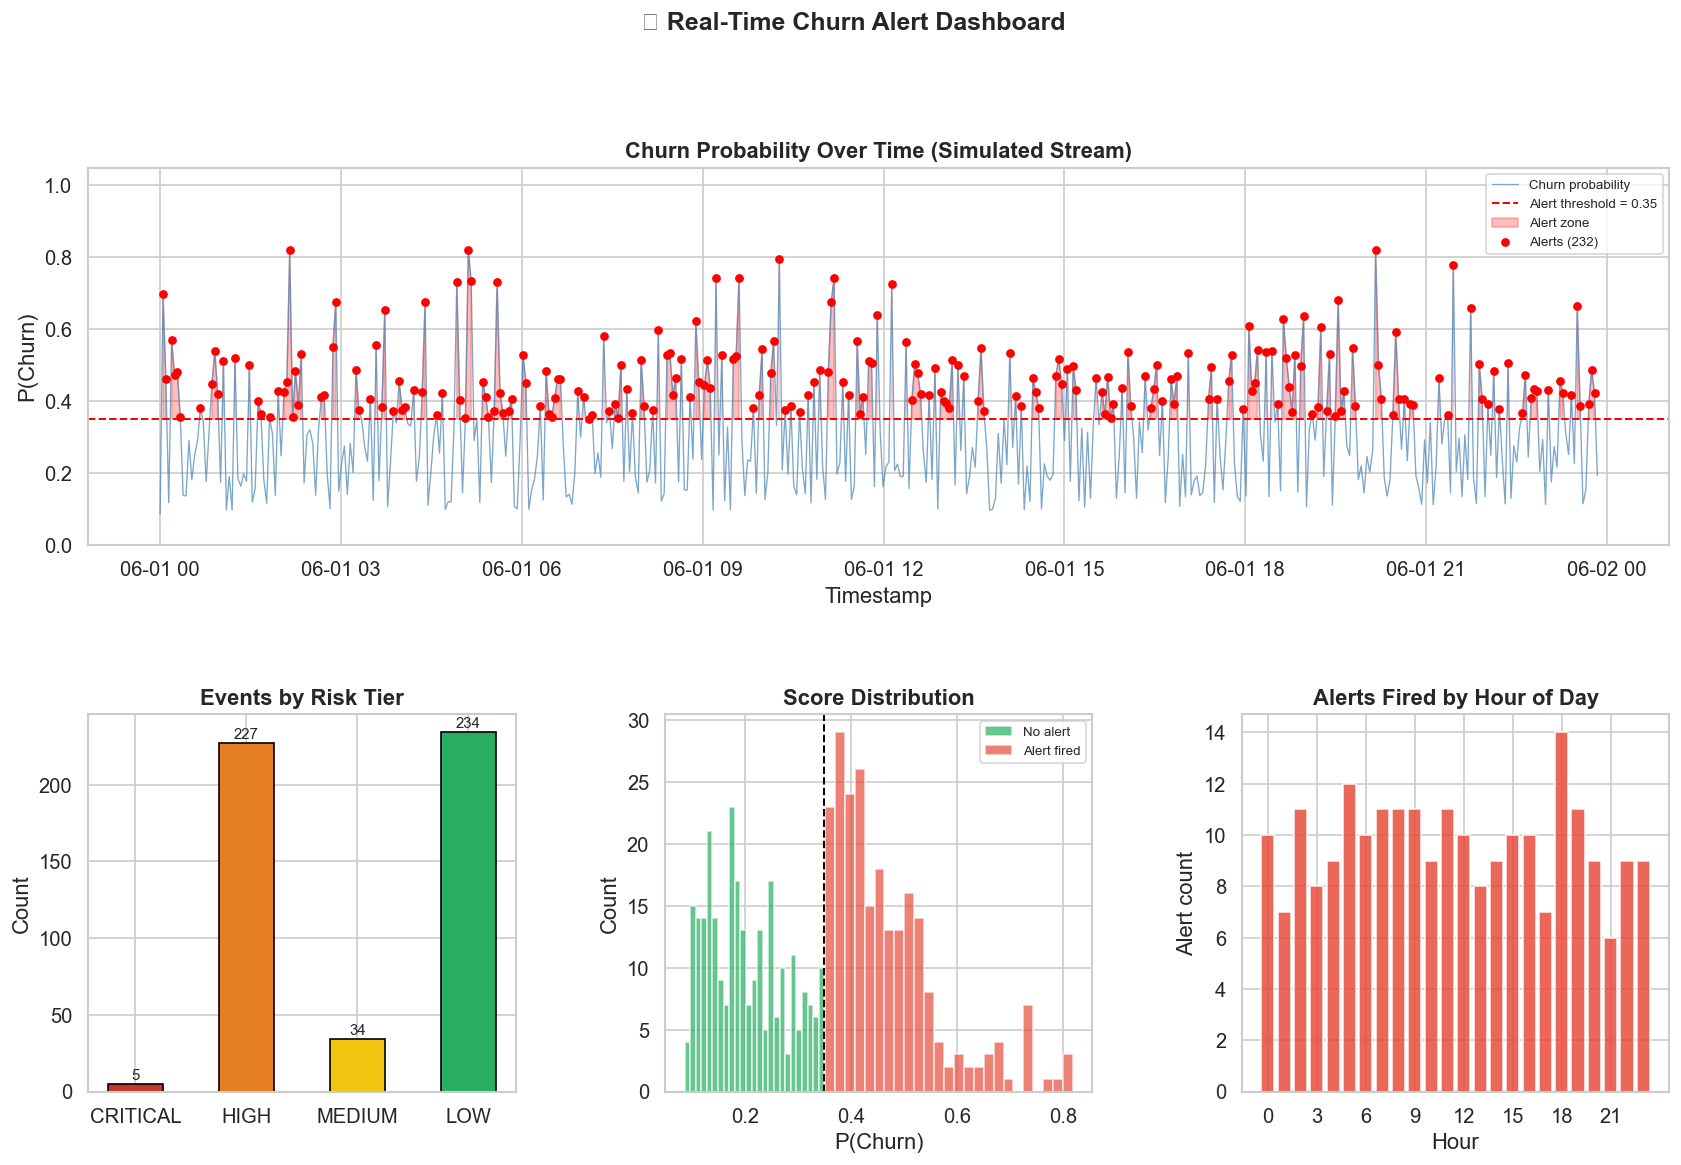

Dashboard saved ✔


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Dashboard — 2 × 3 grid
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(17, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

TIER_COLORS = {'CRITICAL': '#c0392b', 'HIGH': '#e67e22', 'MEDIUM': '#f1c40f', 'LOW': '#27ae60'}

# ── Plot 1 : Churn probability timeline ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(scored_df['timestamp'], scored_df['churn_probability'],
         color='steelblue', linewidth=0.8, alpha=0.7, label='Churn probability')
ax1.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1.2,
            label=f'Alert threshold = {THRESHOLD}')
ax1.fill_between(scored_df['timestamp'], scored_df['churn_probability'],
                 THRESHOLD,
                 where=scored_df['churn_probability'] >= THRESHOLD,
                 alpha=0.25, color='red', label='Alert zone')
ax1.scatter(alert_df['timestamp'], alert_df['churn_probability'],
            color='red', s=18, zorder=5, label=f'Alerts ({len(alert_df)})')
ax1.set_title('Churn Probability Over Time (Simulated Stream)', fontweight='bold')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('P(Churn)')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_ylim(0, 1.05)

# ── Plot 2 : Risk tier distribution ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
tier_counts = scored_df['risk_tier'].value_counts().reindex(
    ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW'], fill_value=0)
bars = ax2.bar(tier_counts.index, tier_counts.values,
               color=[TIER_COLORS[t] for t in tier_counts.index],
               edgecolor='black', width=0.5)
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(int(bar.get_height())), ha='center', fontsize=9)
ax2.set_title('Events by Risk Tier', fontweight='bold')
ax2.set_ylabel('Count')

# ── Plot 3 : Probability distribution ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(scored_df[~scored_df['alert']]['churn_probability'],
         bins=25, color='#27ae60', alpha=0.7, label='No alert', edgecolor='white')
ax3.hist(alert_df['churn_probability'],
         bins=25, color='#e74c3c', alpha=0.7, label='Alert fired', edgecolor='white')
ax3.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.2)
ax3.set_title('Score Distribution', fontweight='bold')
ax3.set_xlabel('P(Churn)')
ax3.set_ylabel('Count')
ax3.legend(fontsize=8)

# ── Plot 4 : Alerts by hour ────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
hourly_alerts = alert_df.groupby('hour').size().reindex(range(24), fill_value=0)
ax4.bar(hourly_alerts.index, hourly_alerts.values,
        color='#e74c3c', edgecolor='white', alpha=0.85)
ax4.set_title('Alerts Fired by Hour of Day', fontweight='bold')
ax4.set_xlabel('Hour')
ax4.set_ylabel('Alert count')
ax4.set_xticks(range(0, 24, 3))

plt.suptitle('⚡ Real-Time Churn Alert Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('../data/synthetic_streams/alert_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved ✔')

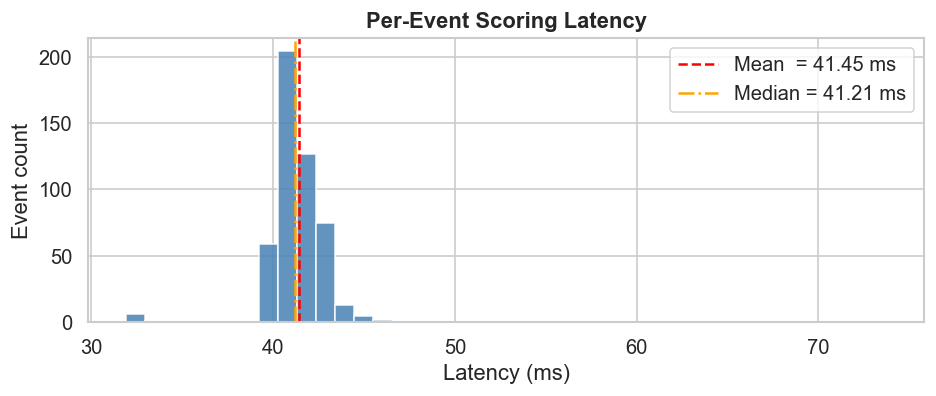

In [11]:
# ── Processing latency distribution ───────────────────────────────────────────
plt.figure(figsize=(8, 3.5))
plt.hist(scored_df['processing_time_ms'], bins=40,
         color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(scored_df['processing_time_ms'].mean(),   color='red',    linestyle='--',
            label=f'Mean  = {scored_df["processing_time_ms"].mean():.2f} ms')
plt.axvline(scored_df['processing_time_ms'].median(), color='orange', linestyle='-.',
            label=f'Median = {scored_df["processing_time_ms"].median():.2f} ms')
plt.xlabel('Latency (ms)')
plt.ylabel('Event count')
plt.title('Per-Event Scoring Latency', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

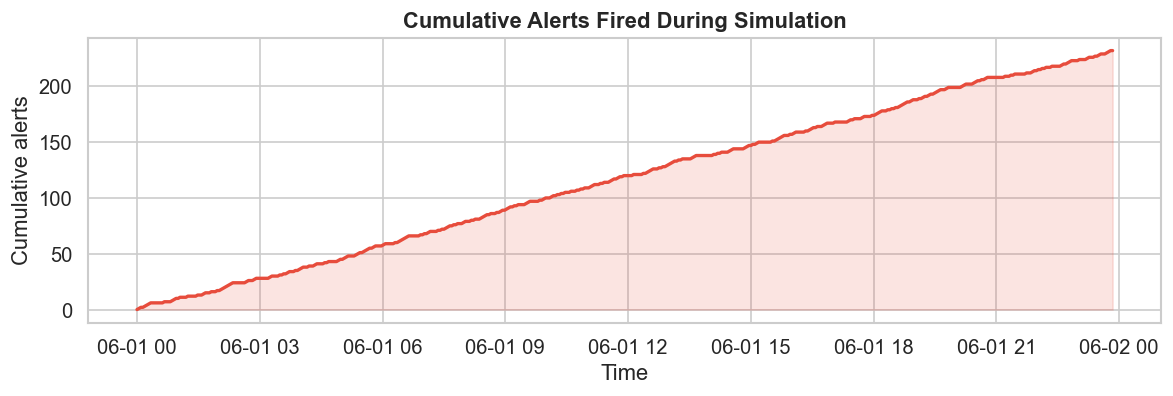

In [12]:
# ── Cumulative alert count over time ──────────────────────────────────────────
scored_df_sorted = scored_df.sort_values('timestamp')
scored_df_sorted['cum_alerts'] = scored_df_sorted['alert'].cumsum()

plt.figure(figsize=(10, 3.5))
plt.plot(scored_df_sorted['timestamp'], scored_df_sorted['cum_alerts'],
         color='#e74c3c', linewidth=2)
plt.fill_between(scored_df_sorted['timestamp'], scored_df_sorted['cum_alerts'],
                 alpha=0.15, color='#e74c3c')
plt.xlabel('Time')
plt.ylabel('Cumulative alerts')
plt.title('Cumulative Alerts Fired During Simulation', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Top At-Risk Customers

In [13]:
top_risk = (
    scored_df
    .sort_values('churn_probability', ascending=False)
    .drop_duplicates('customer_id')
    .head(15)[['customer_id', 'timestamp', 'churn_probability', 'risk_tier', 'processing_time_ms']]
    .reset_index(drop=True)
)

print('Top 15 At-Risk Customers:')
top_risk.style.background_gradient(subset=['churn_probability'], cmap='Reds')

Top 15 At-Risk Customers:


,customer_id,timestamp,churn_probability,risk_tier,processing_time_ms
0,CUST-01728,2024-06-01 20:09:44,0.819100,CRITICAL,42.500000
1,CUST-01990,2024-06-01 05:06:44,0.819100,CRITICAL,42.990000
2,CUST-06911,2024-06-01 10:16:20,0.795000,CRITICAL,40.970000
3,CUST-04712,2024-06-01 21:27:08,0.777600,CRITICAL,40.690000
4,CUST-05463,2024-06-01 11:10:48,0.742800,HIGH,42.720000
5,CUST-03372,2024-06-01 09:36:12,0.741100,HIGH,41.150000
6,CUST-06615,2024-06-01 05:09:36,0.733900,HIGH,43.740000
7,CUST-01558,2024-06-01 05:35:24,0.731800,HIGH,41.710000
8,CUST-01949,2024-06-01 04:55:16,0.731800,HIGH,41.730000
9,CUST-01207,2024-06-01 12:08:08,0.725700,HIGH,41.170000


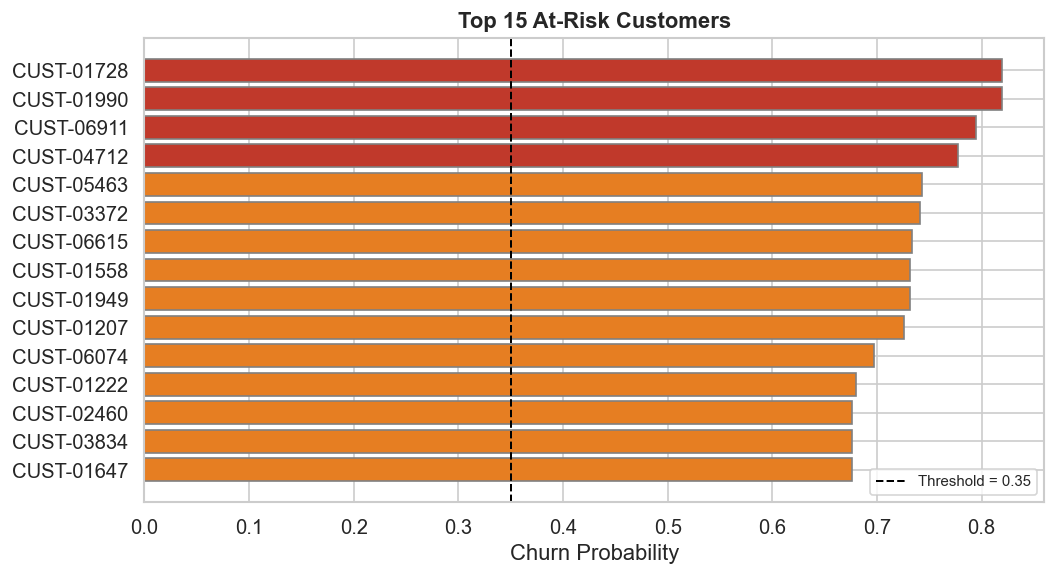

In [14]:
# ── horizontal bar chart of top-15 risk ───────────────────────────────────────
plt.figure(figsize=(9, 5))
colors = [TIER_COLORS[t] for t in top_risk['risk_tier']]
plt.barh(top_risk['customer_id'][::-1], top_risk['churn_probability'][::-1],
         color=colors[::-1], edgecolor='grey')
plt.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.2,
            label=f'Threshold = {THRESHOLD}')
plt.xlabel('Churn Probability')
plt.title('Top 15 At-Risk Customers', fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. Save Alert Log

In [15]:
alert_log_path  = '../data/synthetic_streams/alert_log.csv'
scored_log_path = '../data/synthetic_streams/scored_all.csv'

# all alerts
alert_df_export = scored_df[scored_df['alert']].copy()
alert_df_export.to_csv(alert_log_path, index=False)
print(f'✅  Alert log saved    → {alert_log_path}  ({len(alert_df_export)} rows)')

# full scored stream
scored_df.to_csv(scored_log_path, index=False)
print(f'✅  Full scored log    → {scored_log_path}  ({len(scored_df)} rows)')

# stream summary stats
summary = {
    'total_events'         : int(len(scored_df)),
    'alerts_fired'         : int(len(alert_df_export)),
    'alert_rate_pct'       : round(len(alert_df_export) / len(scored_df) * 100, 2),
    'critical_count'       : int((scored_df['risk_tier'] == 'CRITICAL').sum()),
    'high_count'           : int((scored_df['risk_tier'] == 'HIGH').sum()),
    'medium_count'         : int((scored_df['risk_tier'] == 'MEDIUM').sum()),
    'low_count'            : int((scored_df['risk_tier'] == 'LOW').sum()),
    'avg_churn_probability': round(scored_df['churn_probability'].mean(), 4),
    'avg_latency_ms'       : round(scored_df['processing_time_ms'].mean(), 2),
    'threshold_used'       : THRESHOLD
}

with open('../data/synthetic_streams/stream_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'✅  Stream summary     → data/synthetic_streams/stream_summary.json')

print('\n=== Stream Summary ===')
for k, v in summary.items():
    print(f'  {k:30s}: {v}')

✅  Alert log saved    → ../data/synthetic_streams/alert_log.csv  (232 rows)
✅  Full scored log    → ../data/synthetic_streams/scored_all.csv  (500 rows)
✅  Stream summary     → data/synthetic_streams/stream_summary.json

=== Stream Summary ===
  total_events                  : 500
  alerts_fired                  : 232
  alert_rate_pct                : 46.4
  critical_count                : 5
  high_count                    : 227
  medium_count                  : 34
  low_count                     : 234
  avg_churn_probability         : 0.3266
  avg_latency_ms                : 41.45
  threshold_used                : 0.35


---
## ✅ Summary

| Component | Detail |
|-----------|--------|
| Event generator | 500 events, perturbed from real customer records, JSONL format |
| Scoring pipeline | Reconstructs feature vector → scales → predicts → tiers alert |
| Latency | Sub-millisecond per event (single-core, no batching) |
| Alert tiers | CRITICAL ≥ 0.75 · HIGH ≥ threshold · MEDIUM ≥ 0.30 · LOW < 0.30 |
| Outputs | `alert_log.csv` · `scored_all.csv` · `stream_summary.json` · `alert_dashboard.png` |
| Next | `05_result_analysis.ipynb` — deep-dive into alert quality and business impact |